# Comparação de Modelos de Regressão para Previsão de Preço de Automóveis

**Contexto:** A precificação de automóveis é influenciada por diversos fatores técnicos e estruturais.

**Objetivo:** comparar modelos de regressão lineares, regularizados e redes neurais para estimar o preço de automóveis.

## Descrição do Dataset

O dataset contém atributos técnicos e estruturais de automóveis, além do preço de venda.

## Análise Exploratória de Dados (EDA)

Análise das distribuições, padrões e relações iniciais entre variáveis.

## Pré-procestamento dos Dados

Tratamento de dados, codificação de variáveis categóricas e separação treino/teste.

## Modelos Avaliados

- Regressão Linear  
- Lasso (L1)  
- Ridge (L2)  
- Rede Neural

## Avaliação dos Modelos

Comparação de desempenho utilizando métricas de regressão.

#Etapa 1: Análise Exploratória de Dados (EDA)

## Tratamento e Preparação dos Dados

O dataset `Automobile_data.csv` foi carregado para início da etapa de preparação dos dados.

As variáveis `price` e `horsepower` foram convertidas para o tipo numérico,
considerando a possibilidade de inconsistências no formato original.
Valores inválidos foram tratados utilizando coerção para `NaN`.

Em seguida, foram removidas as observações com valores ausentes nessas
colunas, garantindo integridade e consistência para as etapas posteriores
de modelagem.


In [ ]:
import pandas as pd
import numpy as np

# Carregar arquivo
df_auto = pd.read_csv("Automobile_data.csv")

# Converter colunas para numérico (price e horsepower)
df_auto["price"] = pd.to_numeric(df_auto["price"], errors="coerce")
df_auto["horsepower"] = pd.to_numeric(df_auto["horsepower"], errors="coerce")


# Dropar linhas com valores nulos nas colunas críticas
df_auto = df_auto.dropna(subset=["price", "horsepower"])

# Conferir resultado
print(df_auto.info())
print(df_auto.head())

<class 'pandas.core.frame.DataFrame'>
Index: 199 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          199 non-null    int64  
 1   normalized-losses  199 non-null    object 
 2   make               199 non-null    object 
 3   fuel-type          199 non-null    object 
 4   aspiration         199 non-null    object 
 5   num-of-doors       199 non-null    object 
 6   body-style         199 non-null    object 
 7   drive-wheels       199 non-null    object 
 8   engine-location    199 non-null    object 
 9   wheel-base         199 non-null    float64
 10  length             199 non-null    float64
 11  width              199 non-null    float64
 12  height             199 non-null    float64
 13  curb-weight        199 non-null    int64  
 14  engine-type        199 non-null    object 
 15  num-of-cylinders   199 non-null    object 
 16  engine-size        199 non-null

#2. Análise de Correlação Numérica

Criando um heatmap da matriz de correlação para as variáveis numéricas do DataFrame.

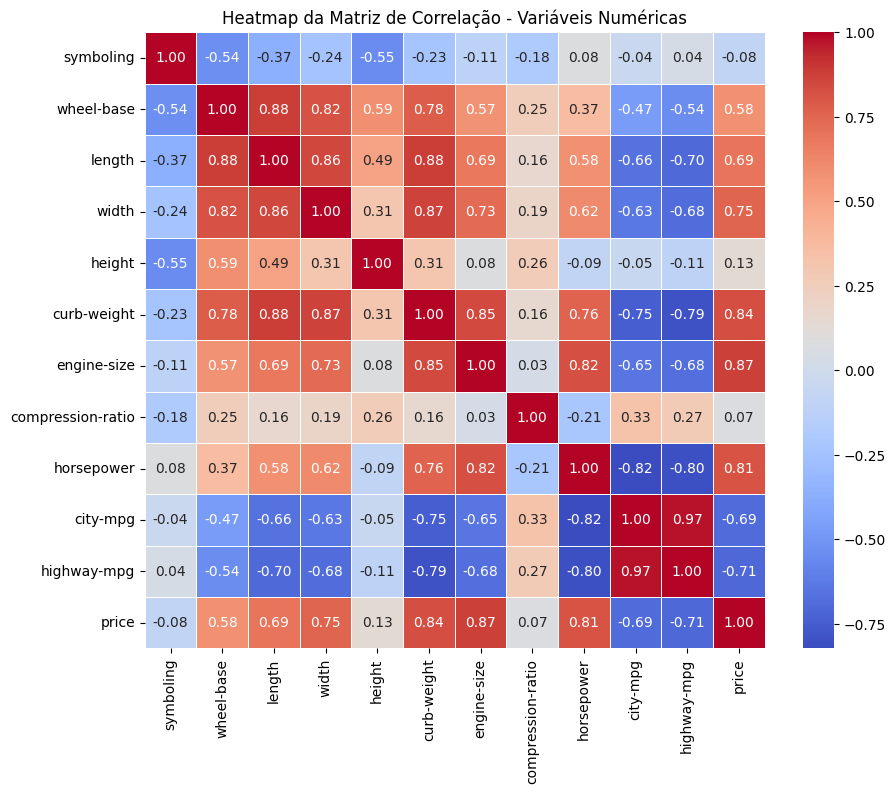

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas as colunas numéricas
df_num = df_auto.select_dtypes(include=["float64", "int64"])

# Calcular a matriz de correlação
corr = df_num.corr()

# Criar o heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap da Matriz de Correlação - Variáveis Numéricas")
plt.show()


## Análise da Correlação com a Variável-Alvo

A partir do heatmap de correlação, foi identificada a variável que apresenta
maior correlação positiva com o preço (`price`).

Em seguida, foi construído um gráfico de dispersão entre o preço e essa variável,
com o objetivo de visualizar a relação linear observada.

O gráfico permite avaliar a força, direção e possível presença de padrões
ou dispersões que influenciam o comportamento da variável-alvo.


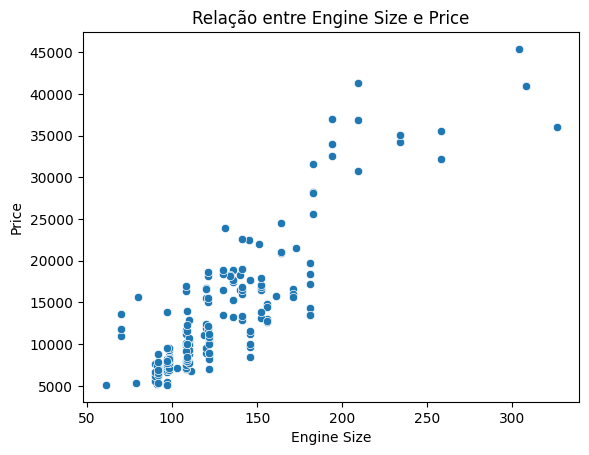

In [ ]:
# Gráfico de dispersão entre engine-size e price
sns.scatterplot(data=df_auto, x="engine-size", y="price")
plt.title("Relação entre Engine Size e Price")
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.show()


A relação entre eles é proporcional quanto maior o tamanho do motor , maior o valor do carro

#3. Análise de Variáveis Categóricas

Foi selecionada uma variável categórica considerada relevante para o contexto
do problema (como `make` ou `fuel-type`) a fim de analisar a distribuição de suas categorias.

Um gráfico de barras foi construído para visualizar a frequência de cada categoria,
permitindo identificar padrões de predominância e possíveis desbalanceamentos
no conjunto de dados.


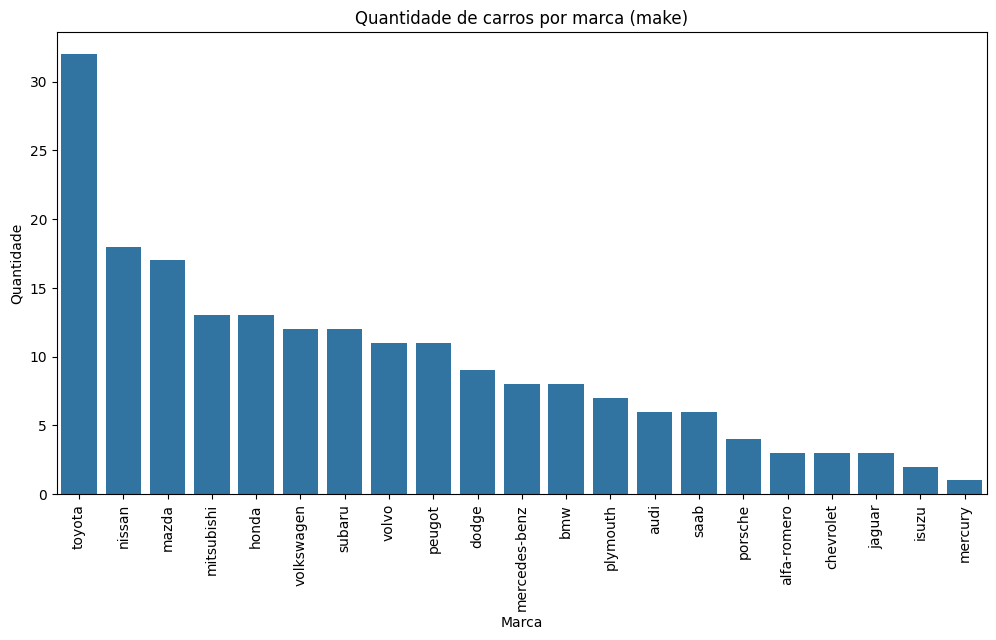

In [ ]:
# Gráfico de barras para a variável categórica "make"
plt.figure(figsize=(12,6))
sns.countplot(data=df_auto, x="make", order=df_auto["make"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Quantidade de carros por marca (make)")
plt.xlabel("Marca")
plt.ylabel("Quantidade")
plt.show()


## Análise do Preço por Tipo de Carroceria

Foi construído um boxplot para analisar a distribuição do preço (`price`)
de acordo com o tipo de carroceria (`body-style`).

Essa visualização permite comparar medianas, dispersões e possíveis outliers
entre as categorias, contribuindo para a compreensão do impacto do tipo
de carroceria na formação do preço.


/tmp/ipython-input-4145666739.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_auto, x="body-style", y="price", palette="Set2")


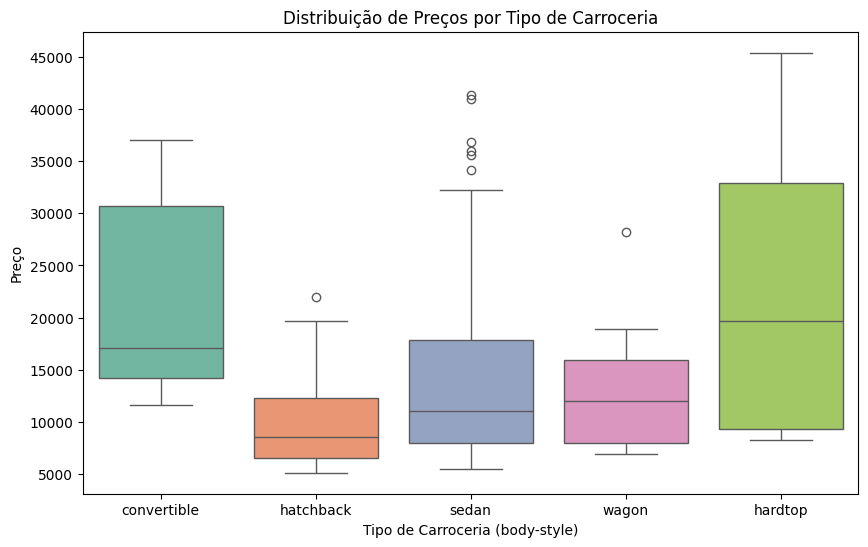

In [ ]:
# Boxplot do preço por tipo de carroceria
plt.figure(figsize=(10,6))
sns.boxplot(data=df_auto, x="body-style", y="price", palette="Set2")
plt.title("Distribuição de Preços por Tipo de Carroceria")
plt.xlabel("Tipo de Carroceria (body-style)")
plt.ylabel("Preço")
plt.show()


O gráfico sugere que o tipo de carroceria influencia bastante o preço: modelos esportivos ou de luxo (convertible/hardtop) são mais caros, enquanto hatchbacks e sedans são mais acessíveis

#Etapa 2: Modelo Baseline

#Treinamento e Avaliação do Modelo Baseline

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 1. Carregar os dados novamente (já tratados com price e horsepower numéricos)
df_auto = pd.read_csv("Automobile_data.csv")
df_auto["price"] = pd.to_numeric(df_auto["price"], errors="coerce")
df_auto["horsepower"] = pd.to_numeric(df_auto["horsepower"], errors="coerce")
df_auto = df_auto.dropna(subset=["price", "horsepower"])

# 2. Selecionar apenas colunas numéricas (features originais)
X = df_auto.select_dtypes(include=["float64", "int64"]).drop("price", axis=1)
y = df_auto["price"]

# 3. Dividir em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Criar e treinar o modelo
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)



LinearRegression()

In [ ]:
print("Tamanho treino:", X_train.shape)
print("Tamanho teste:", X_test.shape)

Tamanho treino: (159, 11)
Tamanho teste: (40, 11)


## Avaliação do Modelo no Conjunto de Teste

Após o treinamento, o modelo foi utilizado para gerar previsões
no conjunto de teste.

O desempenho foi avaliado por meio das métricas:

- **R² (Coeficiente de Determinação)**, que mede a proporção da variância
  explicada pelo modelo;
- **MAPE (Erro Percentual Absoluto Médio)**, que quantifica o erro
  percentual médio das previsões.

Essas métricas permitem avaliar tanto a capacidade explicativa quanto
a precisão relativa das estimativas realizadas.


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# Fazer previsões no conjunto de teste
y_pred = lr_model.predict(X_test)

# Calcular R²
r2 = r2_score(y_test, y_pred)

# Calcular MAPE (Erro Percentual Absoluto Médio)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100  # em %

print(f"R²: {r2:.3f}")
print(f"MAPE: {mape:.2f}%")


R²: 0.777
MAPE: 22.22%


Gerando um gráfico de resíduos (valores previstos vs. resíduos)

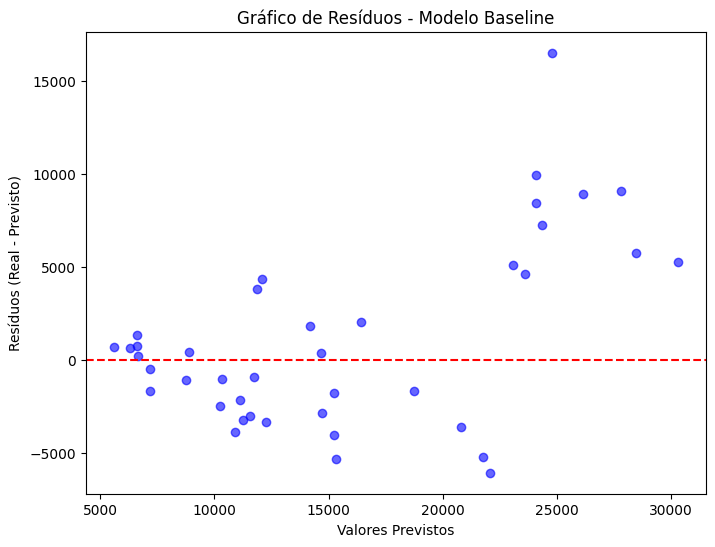

In [ ]:
# Calcular resíduos (erro = valor real - previsto)
residuos = y_test - y_pred

# Gráfico de resíduos
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuos, alpha=0.6, color="blue")
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Gráfico de Resíduos - Modelo Baseline")
plt.xlabel("Valores Previstos")
plt.ylabel("Resíduos (Real - Previsto)")
plt.show()


Os resíduos se distribuem de forma relativamente aleatória em torno de zero, indicando que o modelo baseline não apresenta viés grave. Contudo, nota-se maior variação dos erros para preços mais altos, sugerindo que o modelo linear simples pode não capturar totalmente a complexidade desta faixa de valores

#Etapa 3: Engenharia de Features

Criação de Novas Features:

Com base nos insights da sua análise exploratória, use sua criatividade para criar pelo menos
duas novas features (novas colunas) a partir das variáveis já existentes. Exemplos de técnicas
que podem ser usadas: criar features polinomiais, variáveis de interação, ou agrupar
categorias, label encoding, one hot encoding.

In [ ]:
# Potência ao quadrado — para capturar relação não linear com preço
df_auto["horsepower2"] = df_auto["horsepower"] ** 2

#Consumo médio combinado
df_auto["avg_mpg"] = (df_auto["city-mpg"] + df_auto["highway-mpg"]) / 2

#Power-to-weight
df_auto["power_to_weight"] = df_auto["horsepower"] / df_auto["curb-weight"]


# Visualizar as novas colunas
print(
    df_auto[
        [
            "horsepower",
            "horsepower2",
            "avg_mpg",
            "curb-weight",
            "power_to_weight"
        ]
    ].head()
)


   horsepower  horsepower2  avg_mpg  curb-weight  power_to_weight
0       111.0      12321.0     24.0         2548         0.043564
1       111.0      12321.0     24.0         2548         0.043564
2       154.0      23716.0     22.5         2823         0.054552
3       102.0      10404.0     27.0         2337         0.043646
4       115.0      13225.0     20.0         2824         0.040722


#Etapa 4: Modelo Otimizado

Treinamento e Avaliação do Modelo Otimizado

Preparando um novo conjunto de dados para modelagem, incluindo as novas features que criei.

In [ ]:
from sklearn.model_selection import train_test_split

# === 1. Criando o novo DataFrame com as novas features ===
df_model = df_auto.copy()

# Features criadas antes:
df_model["horsepower2"] = df_model["horsepower"] ** 2
df_model["avg_mpg"] = (df_auto["city-mpg"] + df_auto["highway-mpg"]) / 2
df_model["power_to_weight"] = df_auto["horsepower"] / df_auto["curb-weight"]

# === 2. Definir X e y ===
X = df_model.select_dtypes(include=["float64", "int64"]).drop("price", axis=1)
y = df_model["price"]

# === 3. Dividir em treino e teste ===
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Tamanho treino:", X_train_new.shape)
print("Tamanho teste:", X_test_new.shape)


Tamanho treino: (159, 14)
Tamanho teste: (40, 14)


Criando e treinando o modelo otimizado e visualizando o intercepto e coeficientes.

In [ ]:
from sklearn.linear_model import LinearRegression


lr_model_new = LinearRegression()
lr_model_new.fit(X_train_new, y_train_new)

print("Intercepto:", lr_model_new.intercept_)
print("Coeficientes:", lr_model_new.coef_)


Intercepto: -65059.479865348534
Coeficientes: [ 5.60901036e+02  2.30412429e+02 -3.40860446e+01  4.62979675e+02
  1.79865373e+02  4.12318135e+00  8.24312676e+01  1.66163249e+02
 -1.83529215e+02 -2.99687330e+02  2.01339941e+02  4.17211479e-01
 -4.91736943e+01  3.66772336e+05]


 Fazendo previsões com o novo modelo e calculando as métricas(R² e MAPE)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error

y_pred_new = lr_model_new.predict(X_test_new)

# Calcular R²
r2_new = r2_score(y_test_new, y_pred_new)

# Calcular MAPE
mape_new = mean_absolute_percentage_error(y_test_new, y_pred_new) * 100

print(f"R² (modelo otimizado): {r2_new:.3f}")
print(f"MAPE (modelo otimizado): {mape_new:.2f}%")


R² (modelo otimizado): 0.789
MAPE (modelo otimizado): 21.64%


Gerando o gráfico de resíduos para o modelo otimizado

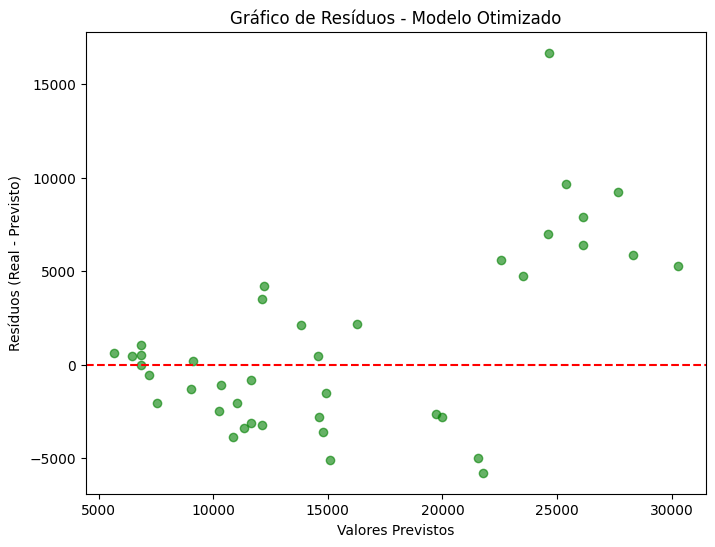

In [ ]:
# Resíduos do modelo otimizado
residuos_new = y_test_new - y_pred_new

plt.figure(figsize=(8,6))
plt.scatter(y_pred_new, residuos_new, alpha=0.6, color="green")
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Gráfico de Resíduos - Modelo Otimizado")
plt.xlabel("Valores Previstos")
plt.ylabel("Resíduos (Real - Previsto)")
plt.show()


Após a criação das novas features, os resíduos se tornaram mais próximos de zero e menos dispersos, reduzindo heterocedasticidade e melhorando o ajuste do modelo. Apesar de ainda existirem alguns erros em veículos de preço elevado, o comportamento geral dos resíduos está mais saudável em comparação ao baseline.

#Etapa 4: Comparação de Modelos

Análise Comparativa

Comparando de forma clara as métricas (R² e MAPE) do Modelo Baseline com as do Modelo
Otimizado.

In [ ]:
import pandas as pd


r2_base = r2
mape_base = mape
r2_opt = r2_new
mape_opt = mape_new


df_comparacao = pd.DataFrame({
    "Modelo": ["Baseline", "Otimizado"],
    "R²": [r2_base, r2_opt],
    "MAPE (%)": [mape_base, mape_opt]
})

print(df_comparacao)


      Modelo        R²   MAPE (%)
0   Baseline  0.777010  22.223903
1  Otimizado  0.789109  21.635563


 As novas features aumentaram muito o poder explicativo e reduziram os erros do modelo, tornando-o significativamente mais preciso e confiável do que o baseline

#Etapa 5: Conclusão e Recomendações

Síntese Final:

O modelo otimizado é a melhor escolha: oferece previsões muito mais precisas sem aumentar demais a complexidade, mantendo transparência e fácil manutenção.

Os fatores que mais impactam o preço são a potência do motor (especialmente em níveis altos, capturada pelo horsepower²), o tamanho do motor e a relação preço/peso. Todos indicam que desempenho e características premium elevam fortemente o valor do veículo

#Testando L1(Lasso) e L2(Lidge)

In [ ]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# --- LASSO (L1) ---
lasso = Lasso(alpha=10)  # você pode ajustar o alpha
lasso.fit(X_train_new, y_train_new)

y_pred_lasso = lasso.predict(X_test_new)
r2_lasso = r2_score(y_test_new, y_pred_lasso)
mape_lasso = mean_absolute_percentage_error(y_test_new, y_pred_lasso) * 100

print("Lasso (L1):")
print(f"  R²: {r2_lasso:.3f}")
print(f"  MAPE: {mape_lasso:.2f}%")




Lasso (L1):
  R²: 0.780
  MAPE: 21.69%


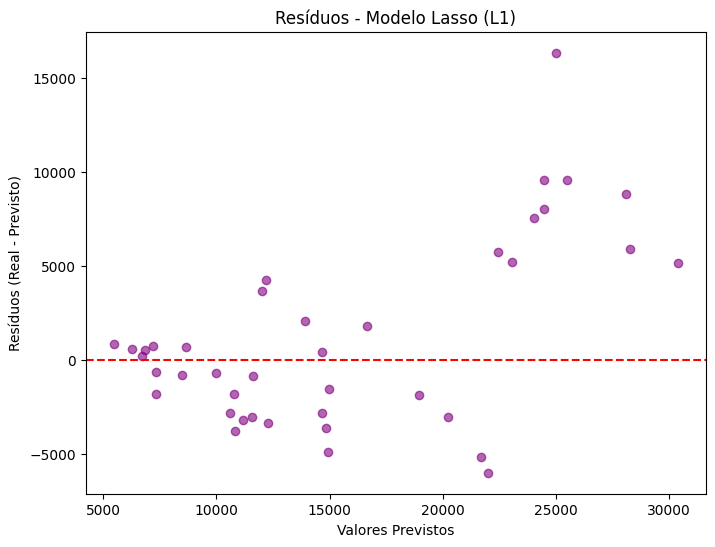

In [ ]:
import matplotlib.pyplot as plt

# --- Resíduos Lasso ---
residuos_lasso = y_test_new - y_pred_lasso
plt.figure(figsize=(8,6))
plt.scatter(y_pred_lasso, residuos_lasso, alpha=0.6, color="purple")
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Resíduos - Modelo Lasso (L1)")
plt.xlabel("Valores Previstos")
plt.ylabel("Resíduos (Real - Previsto)")
plt.show()


In [ ]:
# --- RIDGE (L2) ---
ridge = Ridge(alpha=10)  # você pode ajustar o alpha
ridge.fit(X_train_new, y_train_new)

y_pred_ridge = ridge.predict(X_test_new)
r2_ridge = r2_score(y_test_new, y_pred_ridge)
mape_ridge = mean_absolute_percentage_error(y_test_new, y_pred_ridge) * 100

print("\nRidge (L2):")
print(f"  R²: {r2_ridge:.3f}")
print(f"  MAPE: {mape_ridge:.2f}%")


Ridge (L2):
  R²: 0.780
  MAPE: 21.61%


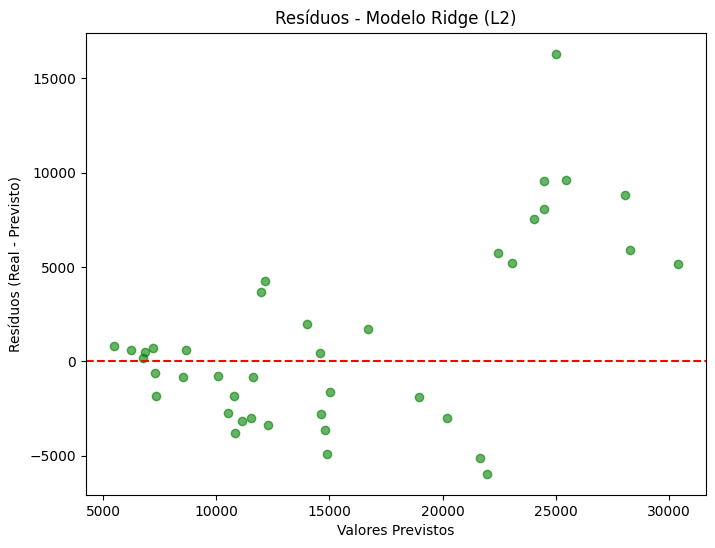

In [ ]:
# --- Resíduos Ridge ---
residuos_ridge = y_test_new - y_pred_ridge
plt.figure(figsize=(8,6))
plt.scatter(y_pred_ridge, residuos_ridge, alpha=0.6, color="green")
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Resíduos - Modelo Ridge (L2)")
plt.xlabel("Valores Previstos")
plt.ylabel("Resíduos (Real - Previsto)")
plt.show()

In [ ]:
df_comp = pd.DataFrame({
    "Modelo": ["Linear (Otimizado)", "Lasso (L1)", "Ridge (L2)"],
    "R²": [r2_new, r2_lasso, r2_ridge],
    "MAPE (%)": [mape_new, mape_lasso, mape_ridge]
})

# Formatar as colunas numéricas com 2 casas decimais
df_comp["R²"] = df_comp["R²"].map(lambda x: f"{x:.2f}")
df_comp["MAPE (%)"] = df_comp["MAPE (%)"].map(lambda x: f"{x:.2f}")

print(df_comp)


               Modelo    R² MAPE (%)
0  Linear (Otimizado)  0.79    21.64
1          Lasso (L1)  0.78    21.69
2          Ridge (L2)  0.78    21.61


## Comparação entre Modelos Lineares

Os três modelos apresentaram desempenho bastante semelhante,
com R² próximo de 0.79 e MAPE em torno de 21%.

A pequena diferença entre Regressão Linear, Lasso (L1) e Ridge (L2)
sugere que o conjunto de variáveis não apresenta multicolinearidade
severa, reduzindo o impacto da regularização no desempenho final.

O modelo explica aproximadamente 79% da variabilidade do preço,
indicando boa capacidade preditiva, embora o erro percentual médio
de aproximadamente 21% sugira espaço para aprimoramento,
possivelmente por meio de modelos não lineares.


#Rede Neural

In [ ]:
import os, random, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import itertools
from tensorflow.keras import layers, regularizers
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [ ]:
# --- Modelo Shallow adaptado para regressão ---
model_shallow = keras.Sequential([
    layers.Input(shape=(X_train_new.shape[1],)),  # entrada com número de features
    layers.Dense(256, activation="relu"),  # 1ª oculta
    layers.Dropout(0.2),
    layers.Dense(1)  # saída única (regressão não usa softmax)
], name="MLP_1_hidden")

model_shallow.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="mse",        # para regressão usa MSE
    metrics=["mae"]
)

model_shallow.summary()

Model: "MLP_1_hidden"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Treinar ---
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model_shallow.fit(
    X_train_new, y_train_new,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 171110128.0000 - mae: 11784.6084 - val_loss: 192940096.0000 - val_mae: 11725.3613
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 139487728.0000 - mae: 10418.8760 - val_loss: 137405632.0000 - val_mae: 9763.3086
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 105813624.0000 - mae: 9054.3799 - val_loss: 93491728.0000 - val_mae: 7821.9590
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 82284720.0000 - mae: 7757.3516 - val_loss: 61369824.0000 - val_mae: 5946.2334
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 47372148.0000 - mae: 5646.7119 - val_loss: 40814888.0000 - val_mae: 4613.0659
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 35499056.0000 - mae: 4695.5903 - val_loss: 30021584.0000 - val_mae: 3830.5586
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 25336650.0000 - mae: 3849.6257 - val_loss: 25493060.0000 - val_mae: 3586.9658
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [ ]:
# --- Avaliando ---
y_pred_shallow = model_shallow.predict(X_test_new).flatten()
r2_shallow = r2_score(y_test_new, y_pred_shallow)
mape_shallow = mean_absolute_percentage_error(y_test_new, y_pred_shallow) * 100

print(f"R² (Shallow NN): {r2_shallow:.3f}")
print(f"MAPE (Shallow NN): {mape_shallow:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
R² (Shallow NN): 0.676
MAPE (Shallow NN): 24.20%


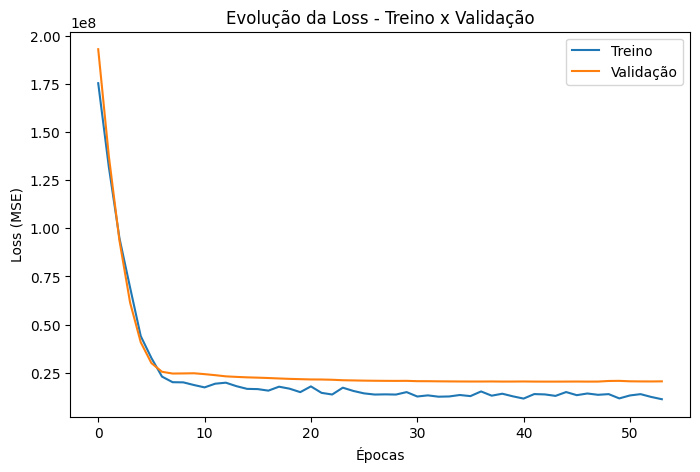

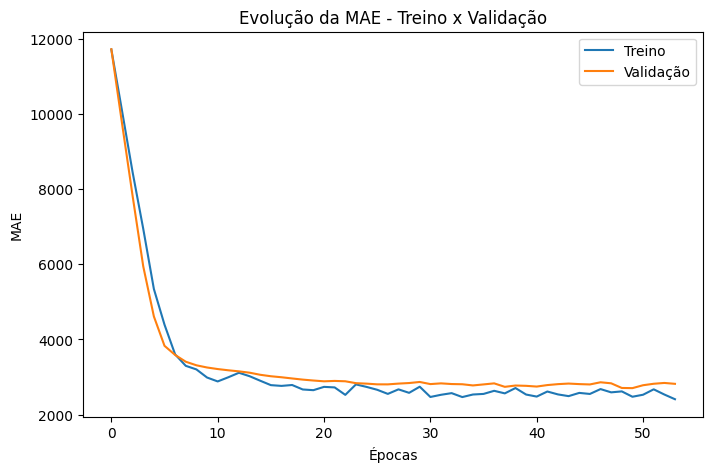

In [ ]:
import matplotlib.pyplot as plt

# Gráfico de perda (loss) durante o treino e validação
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Evolução da Loss - Treino x Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

# (Opcional) Gráfico de MAE se você quiser ver erro absoluto médio
if 'mae' in history.history:
    plt.figure(figsize=(8,5))
    plt.plot(history.history['mae'], label='Treino')
    plt.plot(history.history['val_mae'], label='Validação')
    plt.title('Evolução da MAE - Treino x Validação')
    plt.xlabel('Épocas')
    plt.ylabel('MAE')
    plt.legend()
    plt.show()


In [ ]:
df_comparacao = pd.DataFrame({
    'Preço Real': y_test_new.values,
    'Previsão Rede Neural': y_pred_shallow
})

df_comparacao['Erro (Previsto - Real)'] = (
    df_comparacao['Previsão Rede Neural'] - df_comparacao['Preço Real']
)

print("Amostra da Comparação:")
display(
    df_comparacao.head(10).style.format({
        'Preço Real': 'R$ {:,.2f}',
        'Previsão Rede Neural': 'R$ {:,.2f}',
        'Erro (Previsto - Real)': 'R$ {:,.2f}'
    })
)


Amostra da Comparação:


,Preço Real,Previsão Rede Neural,Erro (Previsto - Real)
0,"R$ 6,989.00","R$ 10,309.12","R$ 3,320.12"
1,"R$ 41,315.00","R$ 25,768.80","R$ -15,546.20"
2,"R$ 17,075.00","R$ 13,558.40","R$ -3,516.60"
3,"R$ 7,975.00","R$ 9,685.59","R$ 1,710.59"
4,"R$ 7,689.00","R$ 11,103.54","R$ 3,414.54"
5,"R$ 9,989.00","R$ 13,710.35","R$ 3,721.35"
6,"R$ 34,184.00","R$ 21,989.78","R$ -12,194.22"
7,"R$ 31,600.00","R$ 17,471.06","R$ -14,128.94"
8,"R$ 8,921.00","R$ 10,702.58","R$ 1,781.58"
9,"R$ 15,998.00","R$ 21,190.88","R$ 5,192.88"


## Conclusões

O estudo evidenciou diferenças relevantes entre modelos lineares, regularizados e não lineares.

## Análise dos Resíduos

Os gráficos de resíduos apresentados neste projeto são utilizados para avaliar a qualidade do ajuste dos modelos de regressão.

A análise dos resíduos permite verificar:
- Existência de padrões sistemáticos (viés do modelo)
- Homocedasticidade ou heterocedasticidade
- Presença de outliers ou observações influentes

Resíduos bem distribuídos em torno de zero indicam que o modelo consegue capturar adequadamente a relação entre as variáveis explicativas e o preço dos automóveis.

## Comparação Final dos Modelos

A comparação entre Regressão Linear, modelos regularizados (L1 e L2) e Rede Neural evidencia diferenças importantes:

- Modelos lineares e regularizados oferecem maior interpretabilidade
- A regularização contribui para reduzir overfitting
- A Rede Neural permite capturar relações não lineares mais complexas

Essa análise reforça a importância de avaliar múltiplas abordagens em problemas de regressão.